# Data Preparation & Initialization

### Set Gobal Seed

In [3]:
Seed = 1

### Import Data

In [4]:
import pandas as pd

df = pd.read_csv("packet-data/for_data.csv")

df.head()

,average_p,channel_10_count,channel_10_mean,channel_10_var,channel_1_count,channel_1_mean,channel_1_var,channel_30_count,channel_30_mean,channel_30_var,...,stream_jitter_60_sum,stream_jitter_60_var,sum_p,tcp_window_size,time_since_previously_displayed_frame,ttl,var_e,var_p,id,label
0,-0.125276,-0.219643,-0.125923,-0.078165,-0.258621,-0.126717,-0.006202,-0.356128,-0.109754,-0.042242,...,0.054332,0.187768,-0.125276,-0.331699,0.824115,1.041916,-0.020802,-0.021891,0,benign
1,1.704444,1.016071,1.084320,1.467455,0.689655,1.290680,0.602265,0.386163,1.066416,1.418354,...,0.024847,-0.018285,1.704444,0.531342,0.008429,0.000000,0.642037,0.641096,2,benign
2,0.359972,-0.107143,0.221685,0.389510,-0.034483,0.324327,0.923591,-0.288549,0.228068,0.399707,...,1.261621,29.710011,0.359972,0.073130,0.216425,-0.053892,1.262787,1.261932,3,benign
3,1.086740,-0.098214,0.833137,0.837415,0.913793,0.838393,1.239748,0.378654,0.789595,0.826501,...,-0.043509,-0.018322,1.086740,0.531342,-0.148788,0.000000,1.165608,1.164739,4,benign
4,-0.032350,-0.207143,-0.046869,-0.058066,-0.224138,0.046838,0.038316,-0.346474,-0.051283,-0.025728,...,0.001234,-0.019592,-0.032350,-0.333876,0.746796,1.035928,0.020973,0.019946,5,benign


### Drop Variables Not Used
- Drop "id" column

In [5]:
# Preserve IDs for linking Phase 2 alerts to Phase 3 flow records.
packet_ids = df["id"].copy() if "id" in df.columns else pd.Series(df.index)

# ID is an identifier, not a behavioral feature.
df = df.drop(columns=["id"], errors="ignore")

df.head()

,average_p,channel_10_count,channel_10_mean,channel_10_var,channel_1_count,channel_1_mean,channel_1_var,channel_30_count,channel_30_mean,channel_30_var,...,stream_jitter_60_mean,stream_jitter_60_sum,stream_jitter_60_var,sum_p,tcp_window_size,time_since_previously_displayed_frame,ttl,var_e,var_p,label
0,-0.125276,-0.219643,-0.125923,-0.078165,-0.258621,-0.126717,-0.006202,-0.356128,-0.109754,-0.042242,...,2.343980,0.054332,0.187768,-0.125276,-0.331699,0.824115,1.041916,-0.020802,-0.021891,benign
1,1.704444,1.016071,1.084320,1.467455,0.689655,1.290680,0.602265,0.386163,1.066416,1.418354,...,-0.175321,0.024847,-0.018285,1.704444,0.531342,0.008429,0.000000,0.642037,0.641096,benign
2,0.359972,-0.107143,0.221685,0.389510,-0.034483,0.324327,0.923591,-0.288549,0.228068,0.399707,...,14.823955,1.261621,29.710011,0.359972,0.073130,0.216425,-0.053892,1.262787,1.261932,benign
3,1.086740,-0.098214,0.833137,0.837415,0.913793,0.838393,1.239748,0.378654,0.789595,0.826501,...,-0.127360,-0.043509,-0.018322,1.086740,0.531342,-0.148788,0.000000,1.165608,1.164739,benign
4,-0.032350,-0.207143,-0.046869,-0.058066,-0.224138,0.046838,0.038316,-0.346474,-0.051283,-0.025728,...,0.216116,0.001234,-0.019592,-0.032350,-0.333876,0.746796,1.035928,0.020973,0.019946,benign


### Create Data Matrix and Label Vector

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate labels for stratification and evaluation; labels are never passed to fit().
X = df.drop(columns=["label"]).to_numpy()
y = df["label"].to_numpy()

print("Data matrix shape:", X.shape)
print("Label vector shape:", y.shape)

row_indices = np.arange(X.shape[0])
X_train, X_remaining, y_train, y_remaining, index_train, index_remaining = train_test_split(
    X, y, row_indices, test_size=0.4, stratify=y, random_state=Seed
)
X_validation, X_test, y_validation, y_test, index_validation, index_test = train_test_split(
    X_remaining,
    y_remaining,
    index_remaining,
    test_size=0.5,
    stratify=y_remaining,
    random_state=Seed,
)

# Fit preprocessing only on the training partition.
phase2_scaler = StandardScaler()
X_train_scaled = phase2_scaler.fit_transform(X_train)
X_validation_scaled = phase2_scaler.transform(X_validation)
X_test_scaled = phase2_scaler.transform(X_test)

print("Train/validation/test sizes:", X_train.shape[0], X_validation.shape[0], X_test.shape[0])
print("Training labels are retained only for analysis, not model fitting.")

Data matrix shape: (195940, 106)
Label vector shape: (195940,)
Train/validation/test sizes: 117564 39188 39188
Training labels are retained only for analysis, not model fitting.


# K-means (high-recall alert generator)

### K-means Hyperparameters Tuning
- Hyperparameters:
    - K: number of clusters used to represent benign behaviour
    - Threshold_percentile: distance cutoff for classifying a sample as anomalous

- Model selection uses validation results 
    - recall >= 0.8 and FPR <= 0.1
    - if non qualify
    - keep configuration with FPR <= 0.1


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score)

k_values = [2, 4, 6, 8, 10, 15, 20]
threshold_percentiles = [80, 85, 90, 92, 95, 97, 99]

# Fit K-means on unlabeled training features; labels are used only for validation.
X_kmeans_train = X_train_scaled
X_evaluation = X_validation_scaled
y_evaluation = y_validation
y_attack = y_validation[y_validation != "benign"]
true_attack = y_evaluation != "benign"

models = {}
thresholds = {}
inertias = []
kmeans_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=5,
        random_state=Seed,
    )
    model.fit(X_kmeans_train)

    # A sample is anomalous when its nearest-centroid distance exceeds
    # the chosen percentile of benign training distances.
    training_distances = model.transform(X_kmeans_train).min(axis=1)
    evaluation_distances = model.transform(X_evaluation).min(axis=1)

    models[k] = model
    inertias.append(model.inertia_)

    for percentile in threshold_percentiles:
        threshold = np.percentile(training_distances, percentile)
        predicted_attack = evaluation_distances > threshold

        precision = precision_score(true_attack, predicted_attack, zero_division=0)
        recall = recall_score(true_attack, predicted_attack, zero_division=0)
        f1 = f1_score(true_attack, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            true_attack, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        thresholds[(k, percentile)] = threshold
        kmeans_results.append({
            "k": k,
            "threshold_percentile": percentile,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "fpr": fpr,
            "fnr": fnr,
        })

        print(
            f"k={k}, percentile={percentile}: Precision={precision:.4f}, "
            f"Recall={recall:.4f}, F1={f1:.4f}"
        )
        print("  Confusion matrix [[TP, FP], [FN, TN]]:")
        print("  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]")
        print(np.array([[tp, fp], [fn, tn]]))
        for attack in sorted(np.unique(y_attack)):
            attack_mask = y_evaluation == attack
            detection_rate = predicted_attack[attack_mask].mean()
            print(f"  {attack} detection rate: {detection_rate:.4f}")

kmeans_results_df = pd.DataFrame(kmeans_results)
display(
    kmeans_results_df.sort_values("fnr", ascending=True).reset_index(drop=True)
)

# Prefer high recall for Phase 2, while limiting validation false alarms.
eligible_kmeans = kmeans_results_df[
    (kmeans_results_df["recall"] >= 0.80) & (kmeans_results_df["fpr"] <= 0.10)
]
if eligible_kmeans.empty:
    eligible_kmeans = kmeans_results_df[kmeans_results_df["fpr"] <= 0.10]
if eligible_kmeans.empty:
    eligible_kmeans = kmeans_results_df
best_kmeans_config = eligible_kmeans.sort_values(
    ["fnr", "fpr", "f1"], ascending=[True, True, False]
).iloc[0]

best_k = int(best_kmeans_config["k"])
best_kmeans_percentile = int(best_kmeans_config["threshold_percentile"])
best_kmeans_model = models[best_k]
best_kmeans_threshold = thresholds[(best_k, best_kmeans_percentile)]
kmeans_test_scores = best_kmeans_model.transform(X_test_scaled).min(axis=1)
kmeans_test_predictions = kmeans_test_scores > best_kmeans_threshold
kmeans_test_truth = y_test != "benign"
kmeans_test_precision = precision_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_test_recall = recall_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_test_f1 = f1_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_tn, kmeans_fp, kmeans_fn, kmeans_tp = confusion_matrix(
    kmeans_test_truth, kmeans_test_predictions, labels=[False, True]
).ravel()
kmeans_test_fpr = kmeans_fp / (kmeans_fp + kmeans_tn)
kmeans_test_fnr = kmeans_fn / (kmeans_fn + kmeans_tp)
kmeans_test_roc_auc = roc_auc_score(kmeans_test_truth, kmeans_test_scores)
kmeans_test_pr_auc = average_precision_score(kmeans_test_truth, kmeans_test_scores)
print(
    f"Final K-means test: k={best_k}, percentile={best_kmeans_percentile}, "
    f"Precision={kmeans_test_precision:.4f}, Recall={kmeans_test_recall:.4f}, "
    f"F1={kmeans_test_f1:.4f}, FPR={kmeans_test_fpr:.4f}, "
    f"FNR={kmeans_test_fnr:.4f}, ROC-AUC={kmeans_test_roc_auc:.4f}, "
    f"PR-AUC={kmeans_test_pr_auc:.4f}"
)
print(np.array([[kmeans_tp, kmeans_fp], [kmeans_fn, kmeans_tn]]))
for attack in sorted(np.unique(y_test[y_test != "benign"])):
    attack_mask = y_test == attack
    print(f"  {attack} detection rate: {kmeans_test_predictions[attack_mask].mean():.4f}")

kmeans_alerts_df = pd.DataFrame({
    "packet_id": packet_ids.iloc[index_test].to_numpy(),
    "true_label": y_test,
    "anomaly_score": kmeans_test_scores,
    "alert": kmeans_test_predictions,
})
kmeans_alerts_df = kmeans_alerts_df[kmeans_alerts_df["alert"]].reset_index(drop=True)

k=2, percentile=80: Precision=0.0672, Recall=0.4487, F1=0.1169
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  533  7396]
 [  655 30604]]
  brute_force detection rate: 0.1435
  ddos detection rate: 0.8228
  dns_spoofing detection rate: 0.2647
  dos detection rate: 0.8908
  xss detection rate: 0.1218
k=2, percentile=85: Precision=0.0850, Recall=0.4268, F1=0.1418
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  507  5457]
 [  681 32543]]
  brute_force detection rate: 0.1224
  ddos detection rate: 0.7806
  dns_spoofing detection rate: 0.2395
  dos detection rate: 0.8908
  xss detection rate: 0.1008
k=2, percentile=90: Precision=0.1192, Recall=0.3973, F1=0.1833
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  472  3489]
 [  716 34511]]
  brute_force detection rate: 0.0717
  ddos detection rate: 0.

,k,threshold_percentile,precision,recall,f1,fpr,fnr
0,20,80,0.082996,0.553030,0.144332,0.191026,0.446970
1,15,80,0.081893,0.534512,0.142026,0.187342,0.465488
2,10,80,0.081575,0.533670,0.141518,0.187842,0.466330
3,8,80,0.080898,0.533670,0.140499,0.189553,0.466330
4,6,80,0.081012,0.533670,0.140670,0.189263,0.466330
5,20,85,0.103999,0.521044,0.173389,0.140342,0.478956
6,4,80,0.077953,0.519360,0.135560,0.192053,0.480640
7,10,85,0.103573,0.507576,0.172040,0.137342,0.492424
8,15,85,0.102727,0.504209,0.170680,0.137684,0.495791
9,6,85,0.098843,0.489057,0.164449,0.139395,0.510943


Final K-means test: k=20, percentile=90, Precision=0.1468, Recall=0.5017, F1=0.2271, FPR=0.0912, FNR=0.4983, ROC-AUC=0.7427, PR-AUC=0.2940
[[  596  3464]
 [  592 34536]]
  brute_force detection rate: 0.2227
  ddos detection rate: 0.8739
  dns_spoofing detection rate: 0.3376
  dos detection rate: 0.9160
  xss detection rate: 0.1561


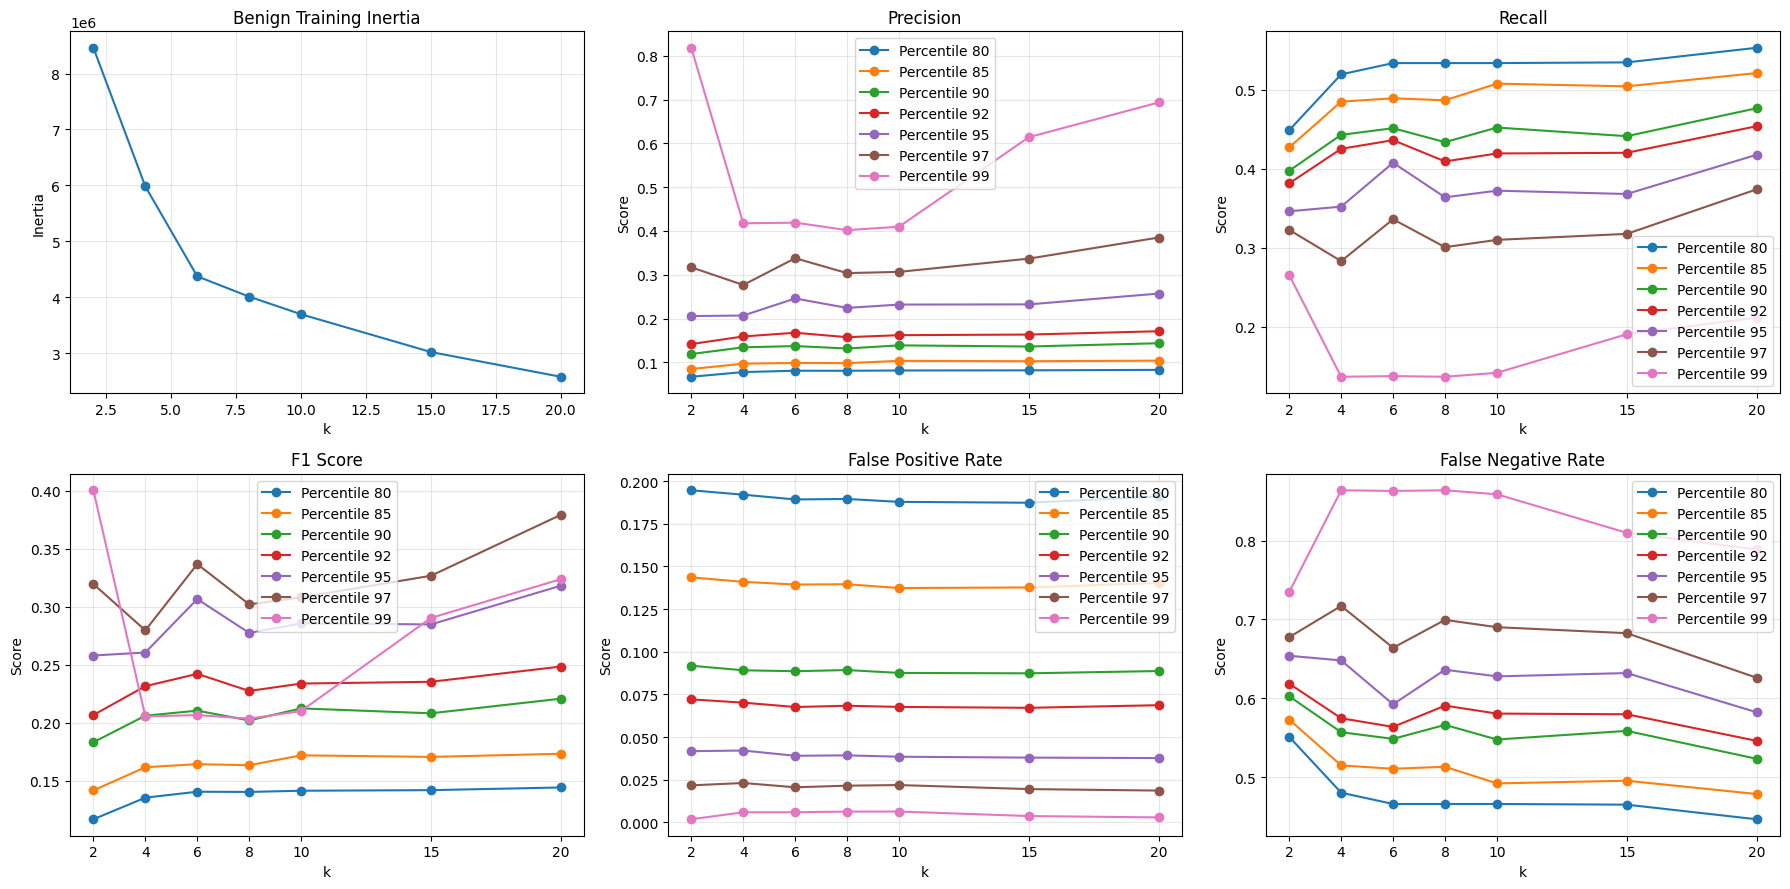

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

# Plot inertia to show how well the model fits the benign training data.
axes[0].plot(k_values, inertias, marker="o")
axes[0].set(title="Benign Training Inertia", xlabel="k", ylabel="Inertia")
axes[0].grid(alpha=0.3)

# Plot each metric for every threshold percentile.
for axis, metric, title in zip(
    axes[1:],
    ["precision", "recall", "f1", "fpr", "fnr"],
    ["Precision", "Recall", "F1 Score", "False Positive Rate", "False Negative Rate"],
):
    for percentile in threshold_percentiles:
        subset = kmeans_results_df[
            kmeans_results_df["threshold_percentile"] == percentile
        ].sort_values("k")
        axis.plot(
            subset["k"], subset[metric], marker="o", label=f"Percentile {percentile}"
        )
    axis.set(title=title, xlabel="k", ylabel="Score")
    axis.set_xticks(k_values)
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

# Autoencoders (high-recall alert generator)

### Autoencoders Hyperparameters Tuning

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score)

keras.utils.set_random_seed(Seed)

bottleneck_sizes = [2, 4, 8, 16, 32]
threshold_percentiles = [80, 85, 90, 92, 95, 97, 99]

# Fit the autoencoder on unlabeled training features.
X_benign_train_ae = X_train_scaled.astype(np.float32)
X_evaluation_ae = X_validation_scaled.astype(np.float32)
y_evaluation_ae = y_validation
y_attack_ae = y_validation[y_validation != "benign"]
true_attack_ae = y_evaluation_ae != "benign"

input_dim = X_benign_train_ae.shape[1]
autoencoder_models = {}
ae_results = []

for bottleneck_size in bottleneck_sizes:
    keras.backend.clear_session()
    keras.utils.set_random_seed(Seed)

    inputs = keras.Input(shape=(input_dim,))
    encoded = keras.layers.Dense(64, activation="relu")(inputs)
    bottleneck = keras.layers.Dense(
        bottleneck_size, activation="relu", name="bottleneck"
    )(encoded)
    decoded = keras.layers.Dense(64, activation="relu")(bottleneck)
    outputs = keras.layers.Dense(input_dim)(decoded)
    autoencoder = keras.Model(inputs, outputs, name=f"autoencoder_{bottleneck_size}")
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    history = autoencoder.fit(
        X_benign_train_ae,
        X_benign_train_ae,
        epochs=50,
        batch_size=512,
        validation_split=0.1,
        shuffle=True,
        callbacks=[early_stopping],
        verbose=0,
    )
    autoencoder_models[bottleneck_size] = autoencoder
    print(f"Bottleneck {bottleneck_size}: trained for {len(history.history['loss'])} epochs")

    train_reconstruction = autoencoder.predict(X_benign_train_ae, verbose=0)
    train_errors = np.mean(
        (X_benign_train_ae - train_reconstruction) ** 2, axis=1
    )
    evaluation_reconstruction = autoencoder.predict(X_evaluation_ae, verbose=0)
    evaluation_errors = np.mean(
        (X_evaluation_ae - evaluation_reconstruction) ** 2, axis=1
    )

    for percentile in threshold_percentiles:
        threshold = np.percentile(train_errors, percentile)
        predicted_attack = evaluation_errors > threshold

        precision = precision_score(
            true_attack_ae, predicted_attack, zero_division=0
        )
        f1 = f1_score(true_attack_ae, predicted_attack, zero_division=0)
        recall = recall_score(true_attack_ae, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            true_attack_ae, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        result = {
            "bottleneck_size": bottleneck_size,
            "threshold_percentile": percentile,
            "threshold": threshold,
            "precision": precision,
            "f1": f1,
            "recall": recall,
            "fpr": fpr,
            "fnr": fnr,
        }
        ae_results.append(result)

        print(
            f"bottleneck={bottleneck_size}, percentile={percentile}: "
            f"Precision={precision:.4f}, Recall={recall:.4f}, "
            f"F1={f1:.4f}"
        )
        print("  Confusion matrix [[TP, FP], [FN, TN]]:")
        print("  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]")
        print(np.array([[tp, fp], [fn, tn]]))
        for attack in sorted(np.unique(y_attack_ae)):
            attack_mask = y_evaluation_ae == attack
            detection_rate = predicted_attack[attack_mask].mean()
            print(f"  {attack} detection rate: {detection_rate:.4f}")

ae_results_df = pd.DataFrame(ae_results)
display(
    ae_results_df.sort_values("fnr", ascending=True).reset_index(drop=True)
)

# Select on validation data: prioritize recall, then control false alarms.
eligible_ae = ae_results_df[
    (ae_results_df["recall"] >= 0.80) & (ae_results_df["fpr"] <= 0.10)
]
if eligible_ae.empty:
    eligible_ae = ae_results_df[ae_results_df["fpr"] <= 0.10]
if eligible_ae.empty:
    eligible_ae = ae_results_df
best_ae_config = eligible_ae.sort_values(
    ["fnr", "fpr", "f1"], ascending=[True, True, False]
).iloc[0]
best_bottleneck_size = int(best_ae_config["bottleneck_size"])
best_ae_percentile = int(best_ae_config["threshold_percentile"])
best_autoencoder = autoencoder_models[best_bottleneck_size]
best_ae_threshold = float(best_ae_config["threshold"])

X_test_ae = X_test_scaled.astype(np.float32)
ae_test_reconstruction = best_autoencoder.predict(X_test_ae, verbose=0)
ae_test_scores = np.mean((X_test_ae - ae_test_reconstruction) ** 2, axis=1)
ae_test_predictions = ae_test_scores > best_ae_threshold
ae_test_truth = y_test != "benign"
ae_test_precision = precision_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_test_recall = recall_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_test_f1 = f1_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_tn, ae_fp, ae_fn, ae_tp = confusion_matrix(
    ae_test_truth, ae_test_predictions, labels=[False, True]
).ravel()
ae_test_fpr = ae_fp / (ae_fp + ae_tn)
ae_test_fnr = ae_fn / (ae_fn + ae_tp)
ae_test_roc_auc = roc_auc_score(ae_test_truth, ae_test_scores)
ae_test_pr_auc = average_precision_score(ae_test_truth, ae_test_scores)
print(
    f"Final autoencoder test: bottleneck={best_bottleneck_size}, "
    f"percentile={best_ae_percentile}, Precision={ae_test_precision:.4f}, "
    f"Recall={ae_test_recall:.4f}, F1={ae_test_f1:.4f}, "
    f"FPR={ae_test_fpr:.4f}, FNR={ae_test_fnr:.4f}, "
    f"ROC-AUC={ae_test_roc_auc:.4f}, PR-AUC={ae_test_pr_auc:.4f}"
)
print(np.array([[ae_tp, ae_fp], [ae_fn, ae_tn]]))
for attack in sorted(np.unique(y_test[y_test != "benign"])):
    attack_mask = y_test == attack
    print(f"  {attack} detection rate: {ae_test_predictions[attack_mask].mean():.4f}")

autoencoder_alerts_df = pd.DataFrame({
    "packet_id": packet_ids.iloc[index_test].to_numpy(),
    "true_label": y_test,
    "anomaly_score": ae_test_scores,
    "alert": ae_test_predictions,
})
autoencoder_alerts_df = autoencoder_alerts_df[
    autoencoder_alerts_df["alert"]
].reset_index(drop=True)

Bottleneck 2: trained for 12 epochs
bottleneck=2, percentile=80: Precision=0.0788, Recall=0.5185, F1=0.1368
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  616  7203]
 [  572 30797]]
  brute_force detection rate: 0.1983
  ddos detection rate: 0.9198
  dns_spoofing detection rate: 0.3445
  dos detection rate: 0.9034
  xss detection rate: 0.2269
bottleneck=2, percentile=85: Precision=0.0987, Recall=0.4891, F1=0.1643
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  581  5304]
 [  607 32696]]
  brute_force detection rate: 0.1646
  ddos detection rate: 0.9198
  dns_spoofing detection rate: 0.2941
  dos detection rate: 0.9034
  xss detection rate: 0.1639
bottleneck=2, percentile=90: Precision=0.1405, Recall=0.4630, F1=0.2156
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  550  3365]
 [  638 34635]]

,bottleneck_size,threshold_percentile,threshold,precision,f1,recall,fpr,fnr
0,32,80,0.013623,0.099703,0.172881,0.649832,0.183447,0.350168
1,32,85,0.016319,0.129015,0.213905,0.625421,0.132000,0.374579
2,4,80,0.117283,0.092308,0.160389,0.611111,0.187868,0.388889
3,8,80,0.066731,0.090623,0.157670,0.606061,0.190132,0.393939
4,16,80,0.030413,0.089908,0.156069,0.590909,0.187000,0.409091
5,32,90,0.021074,0.179860,0.274945,0.583333,0.083158,0.416667
6,4,85,0.142457,0.114804,0.191108,0.569865,0.137368,0.430135
7,8,85,0.080315,0.111706,0.186384,0.562290,0.139789,0.437710
8,16,85,0.037196,0.113548,0.188941,0.562290,0.137237,0.437710
9,32,92,0.024503,0.214609,0.310135,0.558923,0.063947,0.441077


Final autoencoder test: bottleneck=32, percentile=90, Precision=0.1792, Recall=0.6061, F1=0.2767, FPR=0.0868, FNR=0.3939, ROC-AUC=0.7808, PR-AUC=0.3352
[[  720  3297]
 [  468 34703]]
  brute_force detection rate: 0.2815
  ddos detection rate: 0.9664
  dns_spoofing detection rate: 0.5781
  dos detection rate: 0.9370
  xss detection rate: 0.2658


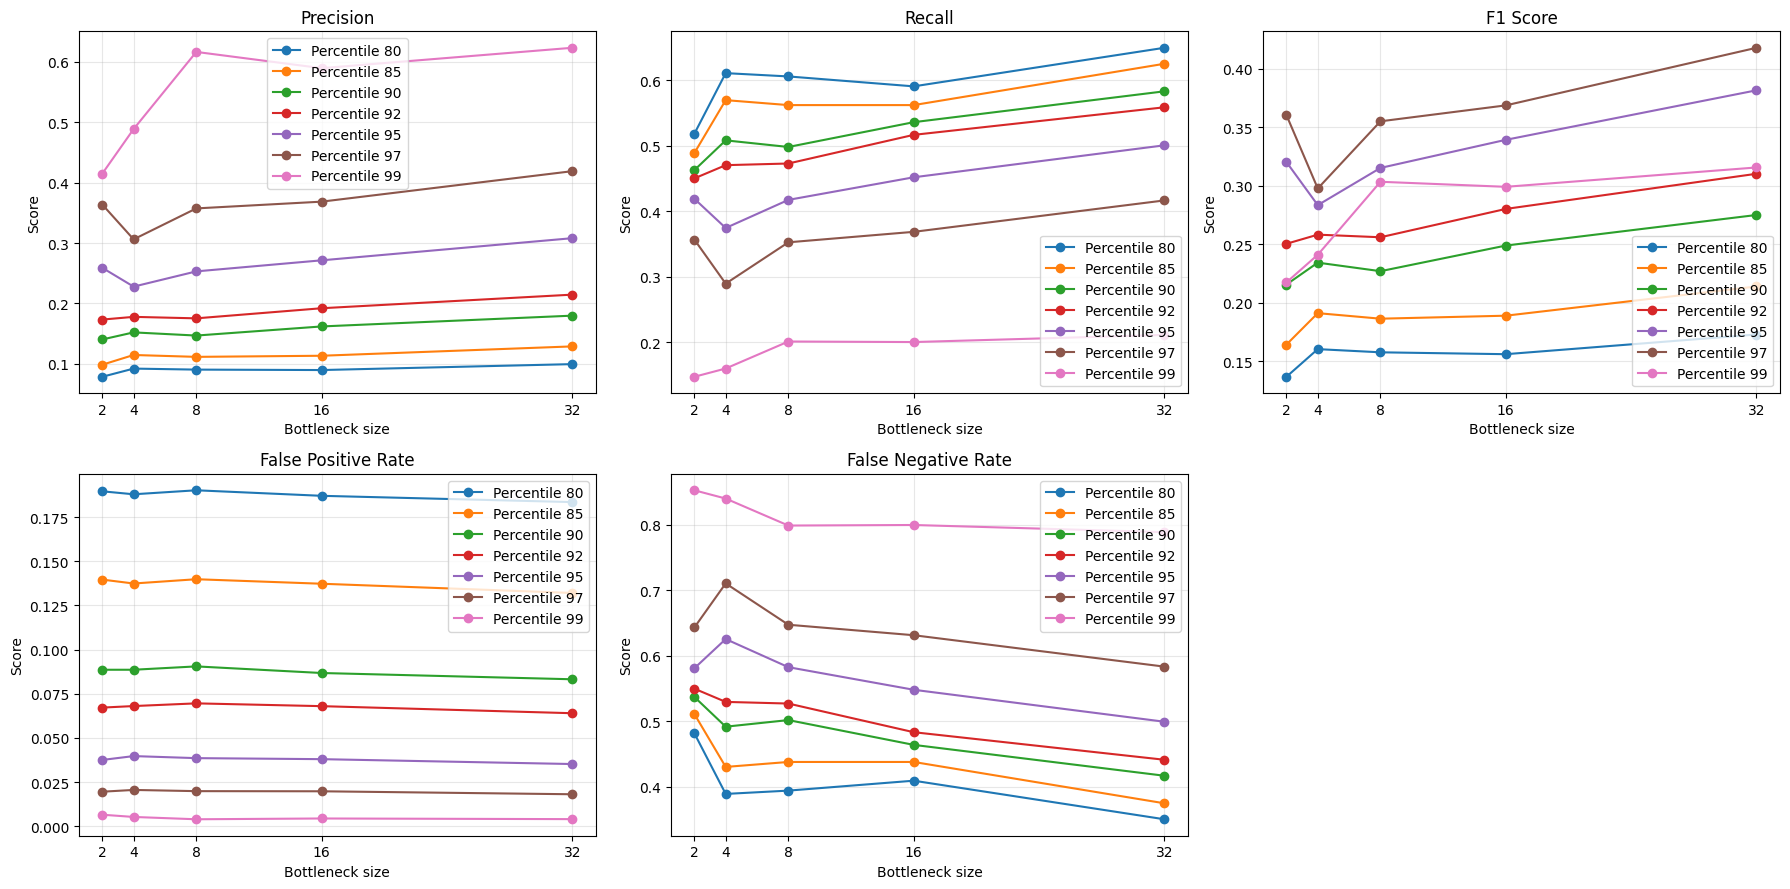

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for axis, metric, title in zip(
    axes[:5],
    ["precision", "recall", "f1", "fpr", "fnr"],
    ["Precision", "Recall", "F1 Score", "False Positive Rate", "False Negative Rate"],
):
    for percentile in threshold_percentiles:
        subset = ae_results_df[
            ae_results_df["threshold_percentile"] == percentile
        ].sort_values("bottleneck_size")
        axis.plot(
            subset["bottleneck_size"],
            subset[metric],
            marker="o",
            label=f"Percentile {percentile}",
        )
    axis.set(title=title, xlabel="Bottleneck size", ylabel="Score")
    axis.set_xticks(bottleneck_sizes)
    axis.grid(alpha=0.3)
    axis.legend()

axes[5].axis("off")
plt.tight_layout()
plt.show()

### Final Phase 2 Test Curves

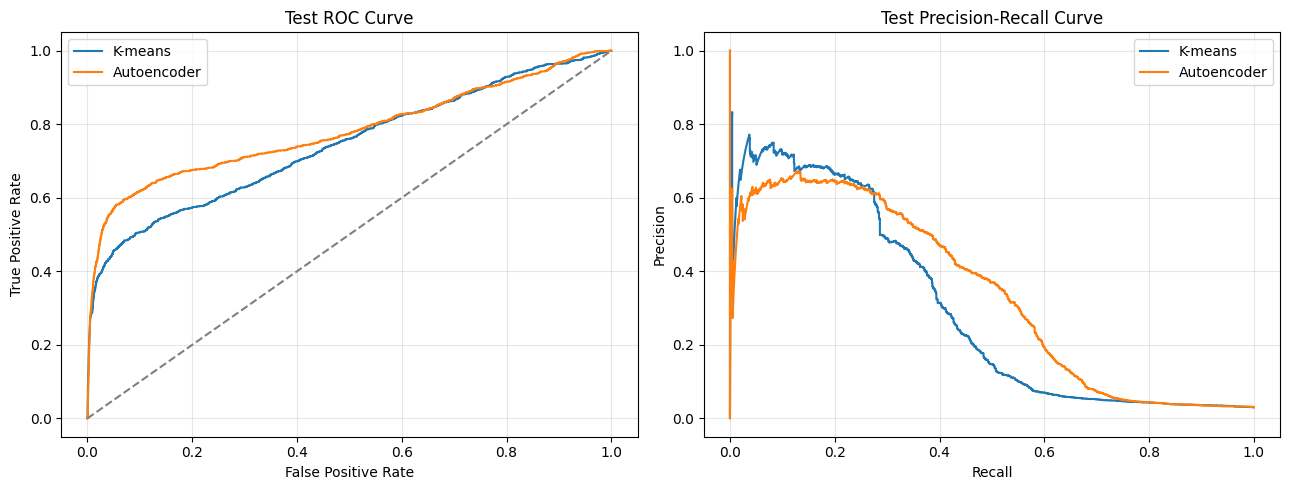

In [11]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, scores in [
    ("K-means", kmeans_test_scores),
    ("Autoencoder", ae_test_scores),
]:
    fpr_curve, tpr_curve, _ = roc_curve(ae_test_truth, scores)
    curve_precision, curve_recall, _ = precision_recall_curve(ae_test_truth, scores)
    axes[0].plot(fpr_curve, tpr_curve, label=name)
    axes[1].plot(curve_recall, curve_precision, label=name)

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(title="Test ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].set(title="Test Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

# Brute-force/session feature engineering experiment

The cells below build an alternate numeric feature table for brute-force-sensitive unsupervised learning. Raw string identifiers such as IP addresses, MAC addresses, and device names are used only as grouping keys, then removed before scaling/modeling so they do not explode dimensionality or distort K-means distances.


In [12]:
import ipaddress
import numpy as np
import pandas as pd

# Step 1: Reload the ForData feature table and packet identity table.
# The identity table gives us source/destination/session fields that are useful grouping keys.
brute_base_df = pd.read_csv("packet-data/for_data.csv")
packet_identity_df = pd.read_csv("packet-data/packet_data_ids.csv")

# Step 2: Join packet identities by packet id.
# We keep labels for evaluation, but labels are not used to construct any feature values.
brute_feature_df = brute_base_df.merge(packet_identity_df, on="id", how="left")

print("Base feature shape:", brute_base_df.shape)
print("Identity table shape:", packet_identity_df.shape)
print("Joined feature shape:", brute_feature_df.shape)
brute_feature_df.head()


Base feature shape: (195940, 108)
Identity table shape: (206000, 11)
Joined feature shape: (195940, 118)


,average_p,channel_10_count,channel_10_mean,channel_10_var,channel_1_count,channel_1_mean,channel_1_var,channel_30_count,channel_30_mean,channel_30_var,...,stream,src_mac,dst_mac,src_ip,dst_ip,src_port,dst_port,device_mac,eth_src_oui,eth_dst_oui
0,-0.125276,-0.219643,-0.125923,-0.078165,-0.258621,-0.126717,-0.006202,-0.356128,-0.109754,-0.042242,...,80,3c:18:a0:41:c3:a0,TP-Link Tapo Camera,34.196.107.165,192.168.137.187,443,57423,TP-Link Tapo Camera,Luxshare Precision Industry Company Limited,TP-Link Corporation Limited
1,1.704444,1.016071,1.084320,1.467455,0.689655,1.290680,0.602265,0.386163,1.066416,1.418354,...,106,Arlo Q Indoor Camera,3c:18:a0:41:c3:a0,192.168.137.175,52.209.141.16,54702,443,Arlo Q Indoor Camera,Netgear,Luxshare Precision Industry Company Limited
2,0.359972,-0.107143,0.221685,0.389510,-0.034483,0.324327,0.923591,-0.288549,0.228068,0.399707,...,648,3c:18:a0:41:c3:a0,e8:1b:69:f8:d6:e6,65.49.38.27,192.168.137.131,443,49747,e8:1b:69:f8:d6:e6,Luxshare Precision Industry Company Limited,Sercomm Corporation.
3,1.086740,-0.098214,0.833137,0.837415,0.913793,0.838393,1.239748,0.378654,0.789595,0.826501,...,79,Arlo Q Indoor Camera,3c:18:a0:41:c3:a0,192.168.137.175,54.74.35.22,56371,443,Arlo Q Indoor Camera,Netgear,Luxshare Precision Industry Company Limited
4,-0.032350,-0.207143,-0.046869,-0.058066,-0.224138,0.046838,0.038316,-0.346474,-0.051283,-0.025728,...,9,3c:18:a0:41:c3:a0,SmartThings Hub,13.59.192.161,192.168.137.186,443,53130,SmartThings Hub,Luxshare Precision Industry Company Limited,"SAMJIN Co., Ltd."


In [13]:
# Step 3: Normalize grouping columns so missing values do not break groupby operations.
# These columns are still not model inputs; they only define behavioral groups.
brute_feature_df = brute_feature_df.sort_values("id").reset_index(drop=True)
brute_feature_df["packet_order"] = np.arange(len(brute_feature_df))

string_group_cols = [
    "stream", "src_mac", "dst_mac", "src_ip", "dst_ip", "device_mac",
    "eth_src_oui", "eth_dst_oui",
]
for col in string_group_cols:
    if col in brute_feature_df.columns:
        brute_feature_df[col] = brute_feature_df[col].fillna("missing").astype(str)

# Step 4: Clean port fields as numeric values.
# Missing or non-IP packets often have port 0; we keep that as a separate behavior signal.
for col in ["src_port", "dst_port"]:
    brute_feature_df[col] = pd.to_numeric(brute_feature_df[col], errors="coerce").fillna(0).astype(int)


/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/2877020922.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  brute_feature_df["packet_order"] = np.arange(len(brute_feature_df))


In [14]:
# Step 5: Add small, low-dimensional IP/port semantic flags.
# These avoid one-hot encoding raw IPs while still preserving useful network meaning.
def safe_ip_flag(value, attr):
    try:
        return int(getattr(ipaddress.ip_address(str(value)), attr))
    except ValueError:
        return 0

brute_feature_df["src_ip_is_private"] = brute_feature_df["src_ip"].apply(lambda x: safe_ip_flag(x, "is_private"))
brute_feature_df["dst_ip_is_private"] = brute_feature_df["dst_ip"].apply(lambda x: safe_ip_flag(x, "is_private"))
brute_feature_df["dst_ip_is_multicast"] = brute_feature_df["dst_ip"].apply(lambda x: safe_ip_flag(x, "is_multicast"))
brute_feature_df["dst_ip_is_loopback"] = brute_feature_df["dst_ip"].apply(lambda x: safe_ip_flag(x, "is_loopback"))

# Step 6: Add compact port-class indicators that are useful for brute-force behavior.
login_or_web_ports = {21, 22, 23, 80, 443, 8080, 8443}
brute_feature_df["dst_port_is_login_or_web"] = brute_feature_df["dst_port"].isin(login_or_web_ports).astype(int)
brute_feature_df["dst_port_is_well_known"] = ((brute_feature_df["dst_port"] > 0) & (brute_feature_df["dst_port"] < 1024)).astype(int)
brute_feature_df["src_port_is_ephemeral"] = (brute_feature_df["src_port"] >= 49152).astype(int)
brute_feature_df["has_valid_ports"] = ((brute_feature_df["src_port"] > 0) & (brute_feature_df["dst_port"] > 0)).astype(int)


/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/452007203.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  brute_feature_df["src_ip_is_private"] = brute_feature_df["src_ip"].apply(lambda x: safe_ip_flag(x, "is_private"))
/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/452007203.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  brute_feature_df["dst_ip_is_private"] = brute_feature_df["dst_ip"].apply(lambda x: safe_ip_flag(x, "is_private"))
/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipyker

In [15]:
# Step 7: Add backward-looking repetition counts.
# These are better for anomaly detection than global one-hot identity features because they measure behavior.
# cumcount() uses only packets seen earlier in id order plus the current packet.
brute_feature_df["src_packets_seen_so_far"] = brute_feature_df.groupby("src_ip").cumcount() + 1
brute_feature_df["src_dst_packets_seen_so_far"] = brute_feature_df.groupby(["src_ip", "dst_ip"]).cumcount() + 1
brute_feature_df["src_dst_port_packets_seen_so_far"] = brute_feature_df.groupby(["src_ip", "dst_ip", "dst_port"]).cumcount() + 1
brute_feature_df["stream_packets_seen_so_far"] = brute_feature_df.groupby("stream").cumcount() + 1

# Step 8: Add cumulative unique-count features for source behavior.
# These capture whether a source is spreading attempts across many destinations or ports.
brute_feature_df["src_unique_dst_ips_seen_so_far"] = (
    (~brute_feature_df.duplicated(["src_ip", "dst_ip"]))
    .groupby(brute_feature_df["src_ip"])
    .cumsum()
    .astype(int)
)
brute_feature_df["src_unique_dst_ports_seen_so_far"] = (
    (~brute_feature_df.duplicated(["src_ip", "dst_port"]))
    .groupby(brute_feature_df["src_ip"])
    .cumsum()
    .astype(int)
)
brute_feature_df["stream_unique_dst_ips_seen_so_far"] = (
    (~brute_feature_df.duplicated(["stream", "dst_ip"]))
    .groupby(brute_feature_df["stream"])
    .cumsum()
    .astype(int)
)
brute_feature_df["stream_unique_dst_ports_seen_so_far"] = (
    (~brute_feature_df.duplicated(["stream", "dst_port"]))
    .groupby(brute_feature_df["stream"])
    .cumsum()
    .astype(int)
)


/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/624102379.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  brute_feature_df["src_packets_seen_so_far"] = brute_feature_df.groupby("src_ip").cumcount() + 1
/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/624102379.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  brute_feature_df["src_dst_packets_seen_so_far"] = brute_feature_df.groupby(["src_ip", "dst_ip"]).cumcount() + 1
/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/624102379.py:

In [16]:
# Step 9: Add brute-force-oriented ratios.
# High repeated attempts to the same destination/port, especially on login/web ports, are suspicious.
eps = 1e-9
brute_feature_df["src_dst_port_repeat_ratio"] = (
    brute_feature_df["src_dst_port_packets_seen_so_far"] /
    (brute_feature_df["src_packets_seen_so_far"] + eps)
)
brute_feature_df["src_dst_repeat_ratio"] = (
    brute_feature_df["src_dst_packets_seen_so_far"] /
    (brute_feature_df["src_packets_seen_so_far"] + eps)
)
brute_feature_df["src_dst_port_login_attempt_score"] = (
    brute_feature_df["src_dst_port_packets_seen_so_far"] *
    brute_feature_df["dst_port_is_login_or_web"]
)
brute_feature_df["src_port_diversity_ratio"] = (
    brute_feature_df["src_unique_dst_ports_seen_so_far"] /
    (brute_feature_df["src_packets_seen_so_far"] + eps)
)
brute_feature_df["src_dst_diversity_ratio"] = (
    brute_feature_df["src_unique_dst_ips_seen_so_far"] /
    (brute_feature_df["src_packets_seen_so_far"] + eps)
)


/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/780544465.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  brute_feature_df["src_dst_port_repeat_ratio"] = (
/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/780544465.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  brute_feature_df["src_dst_repeat_ratio"] = (
/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/780544465.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` man

In [17]:
# Step 10: Add packet-window activity counts without using raw string values as model inputs.
# These approximate short-term behavior using packet order because this table does not include an absolute timestamp.
# If a real timestamp is available in earlier preprocessing, replace this with time-based rolling windows.
def add_packet_window_count(frame, group_cols, output_col, window_packets):
    counts = []
    group_values = frame[group_cols].astype(str).agg("|".join, axis=1)
    for i, key in enumerate(group_values):
        start = max(0, i - window_packets + 1)
        counts.append((group_values.iloc[start:i + 1] == key).sum())
    frame[output_col] = counts

add_packet_window_count(brute_feature_df, ["src_ip"], "src_count_last_100_packets", 100)
add_packet_window_count(brute_feature_df, ["src_ip", "dst_ip"], "src_dst_count_last_100_packets", 100)
add_packet_window_count(brute_feature_df, ["src_ip", "dst_ip", "dst_port"], "src_dst_port_count_last_100_packets", 100)
add_packet_window_count(brute_feature_df, ["src_ip", "dst_ip", "dst_port"], "src_dst_port_count_last_500_packets", 500)


/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/3037339688.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[output_col] = counts
/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/3037339688.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[output_col] = counts
/var/folders/0m/_hz3ft2s6md80rlz1dzk50sw0000gn/T/ipykernel_205/3037339688.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.

In [18]:
# Step 11: Build a numeric-only modeling table.
# Raw identifiers are dropped so K-means/autoencoder distances are based on behavior, not categorical identity.
raw_identifier_cols = [
    "src_mac", "dst_mac", "src_ip", "dst_ip", "device_mac",
    "eth_src_oui", "eth_dst_oui", "stream",
]
target_cols = ["label"]

brute_model_df = brute_feature_df.drop(columns=raw_identifier_cols, errors="ignore")

# Keep only numeric features plus label/id for splitting and evaluation.
numeric_feature_cols = brute_model_df.drop(columns=target_cols, errors="ignore").select_dtypes(include=[np.number]).columns.tolist()
brute_model_df = brute_model_df[numeric_feature_cols + target_cols]

# Replace any remaining infinite values from ratios and fill numeric missing values.
numeric_cols = brute_model_df.drop(columns=target_cols, errors="ignore").columns
brute_model_df[numeric_cols] = brute_model_df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

print("Numeric-only brute-force feature table shape:", brute_model_df.shape)
print("Added numeric features:")
added_cols = sorted(set(brute_model_df.columns) - set(brute_base_df.columns))
print(added_cols)
brute_model_df.head()


Numeric-only brute-force feature table shape: (195940, 136)
Added numeric features:
['dst_ip_is_loopback', 'dst_ip_is_multicast', 'dst_ip_is_private', 'dst_port', 'dst_port_is_login_or_web', 'dst_port_is_well_known', 'has_valid_ports', 'packet_order', 'src_count_last_100_packets', 'src_dst_count_last_100_packets', 'src_dst_diversity_ratio', 'src_dst_packets_seen_so_far', 'src_dst_port_count_last_100_packets', 'src_dst_port_count_last_500_packets', 'src_dst_port_login_attempt_score', 'src_dst_port_packets_seen_so_far', 'src_dst_port_repeat_ratio', 'src_dst_repeat_ratio', 'src_ip_is_private', 'src_packets_seen_so_far', 'src_port', 'src_port_diversity_ratio', 'src_port_is_ephemeral', 'src_unique_dst_ips_seen_so_far', 'src_unique_dst_ports_seen_so_far', 'stream_packets_seen_so_far', 'stream_unique_dst_ips_seen_so_far', 'stream_unique_dst_ports_seen_so_far']


,average_p,channel_10_count,channel_10_mean,channel_10_var,channel_1_count,channel_1_mean,channel_1_var,channel_30_count,channel_30_mean,channel_30_var,...,src_dst_port_repeat_ratio,src_dst_repeat_ratio,src_dst_port_login_attempt_score,src_port_diversity_ratio,src_dst_diversity_ratio,src_count_last_100_packets,src_dst_count_last_100_packets,src_dst_port_count_last_100_packets,src_dst_port_count_last_500_packets,label
0,-0.125276,-0.219643,-0.125923,-0.078165,-0.258621,-0.126717,-0.006202,-0.356128,-0.109754,-0.042242,...,1.0,1.0,0,1.0,1.0,1,1,1,1,benign
1,1.704444,1.016071,1.084320,1.467455,0.689655,1.290680,0.602265,0.386163,1.066416,1.418354,...,1.0,1.0,1,1.0,1.0,1,1,1,1,benign
2,0.359972,-0.107143,0.221685,0.389510,-0.034483,0.324327,0.923591,-0.288549,0.228068,0.399707,...,1.0,1.0,0,1.0,1.0,1,1,1,1,benign
3,1.086740,-0.098214,0.833137,0.837415,0.913793,0.838393,1.239748,0.378654,0.789595,0.826501,...,0.5,0.5,1,0.5,1.0,2,1,1,1,benign
4,-0.032350,-0.207143,-0.046869,-0.058066,-0.224138,0.046838,0.038316,-0.346474,-0.051283,-0.025728,...,1.0,1.0,0,1.0,1.0,1,1,1,1,benign


In [19]:
# Step 12: Create a train/validation/test split for this engineered feature set.
# This mirrors the earlier notebook split logic so results are comparable to the current ForData baseline.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_brute = brute_model_df.drop(columns=["label"], errors="ignore").to_numpy()
y_brute = brute_model_df["label"].to_numpy()

brute_row_indices = np.arange(X_brute.shape[0])
X_brute_train, X_brute_remaining, y_brute_train, y_brute_remaining, index_brute_train, index_brute_remaining = train_test_split(
    X_brute,
    y_brute,
    brute_row_indices,
    test_size=0.4,
    stratify=y_brute,
    random_state=Seed,
)
X_brute_validation, X_brute_test, y_brute_validation, y_brute_test, index_brute_validation, index_brute_test = train_test_split(
    X_brute_remaining,
    y_brute_remaining,
    index_brute_remaining,
    test_size=0.5,
    stratify=y_brute_remaining,
    random_state=Seed,
)

# Step 13: Fit scaling only on the training partition to avoid validation/test leakage.
brute_scaler = StandardScaler()
X_brute_train_scaled = brute_scaler.fit_transform(X_brute_train)
X_brute_validation_scaled = brute_scaler.transform(X_brute_validation)
X_brute_test_scaled = brute_scaler.transform(X_brute_test)

print("Engineered data matrix shape:", X_brute.shape)
print("Train/validation/test sizes:", X_brute_train.shape[0], X_brute_validation.shape[0], X_brute_test.shape[0])
print("Use X_brute_train_scaled, X_brute_validation_scaled, and X_brute_test_scaled to rerun K-means/autoencoder.")


Engineered data matrix shape: (195940, 135)
Train/validation/test sizes: 117564 39188 39188
Use X_brute_train_scaled, X_brute_validation_scaled, and X_brute_test_scaled to rerun K-means/autoencoder.


# Rerun K-means and autoencoder on engineered brute-force/session features

These cells reuse the numeric-only feature matrix created above: `X_brute_train_scaled`, `X_brute_validation_scaled`, and `X_brute_test_scaled`. They keep results in new variables prefixed with `brute_` so the original ForData baseline remains available for comparison.


In [20]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

# Step 1: Define a shared metric reporter for binary anomaly detection.
# The model predicts only benign vs attack; per-type detection rates are computed using the original labels.
def summarize_attack_detection(y_true_labels, predicted_attack, anomaly_scores=None, prefix=""):
    true_attack = y_true_labels != "benign"
    precision = precision_score(true_attack, predicted_attack, zero_division=0)
    recall = recall_score(true_attack, predicted_attack, zero_division=0)
    f1 = f1_score(true_attack, predicted_attack, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(true_attack, predicted_attack, labels=[False, True]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0

    metrics = {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr,
    }

    if anomaly_scores is not None:
        metrics["roc_auc"] = roc_auc_score(true_attack, anomaly_scores)
        metrics["pr_auc"] = average_precision_score(true_attack, anomaly_scores)

    print(
        f"{prefix}Precision={precision:.4f}, Recall={recall:.4f}, "
        f"F1={f1:.4f}, FPR={fpr:.4f}, FNR={fnr:.4f}"
    )
    if anomaly_scores is not None:
        print(f"{prefix}ROC-AUC={metrics['roc_auc']:.4f}, PR-AUC={metrics['pr_auc']:.4f}")

    print(f"{prefix}Confusion matrix [[TP, FP], [FN, TN]]:")
    print(np.array([[tp, fp], [fn, tn]]))

    for attack in sorted(np.unique(y_true_labels[y_true_labels != "benign"])):
        attack_mask = y_true_labels == attack
        detection_rate = predicted_attack[attack_mask].mean()
        metrics[f"{attack}_detection_rate"] = detection_rate
        print(f"{prefix}{attack} detection rate: {detection_rate:.4f}")

    return metrics


In [21]:
# Step 2: Rerun K-means on the engineered brute-force/session feature set.
# Labels are used only for validation/testing, not for fitting clusters.
brute_k_values = [2, 4, 6, 8, 10, 15, 20]
brute_threshold_percentiles = [80, 85, 90, 92, 95, 97, 99]

brute_kmeans_models = {}
brute_kmeans_thresholds = {}
brute_kmeans_results = []

brute_validation_truth = y_brute_validation != "benign"

for k in brute_k_values:
    # Step 2a: Fit K-means using only the engineered training features.
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=5,
        random_state=Seed,
    )
    model.fit(X_brute_train_scaled)
    brute_kmeans_models[k] = model

    # Step 2b: Convert nearest-centroid distance into an anomaly score.
    train_distances = model.transform(X_brute_train_scaled).min(axis=1)
    validation_distances = model.transform(X_brute_validation_scaled).min(axis=1)

    for percentile in brute_threshold_percentiles:
        # Step 2c: Use a percentile of training distances as the anomaly threshold.
        threshold = np.percentile(train_distances, percentile)
        predicted_attack = validation_distances > threshold

        precision = precision_score(brute_validation_truth, predicted_attack, zero_division=0)
        recall = recall_score(brute_validation_truth, predicted_attack, zero_division=0)
        f1 = f1_score(brute_validation_truth, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            brute_validation_truth, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        brute_kmeans_thresholds[(k, percentile)] = threshold
        brute_kmeans_results.append({
            "k": k,
            "threshold_percentile": percentile,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "fpr": fpr,
            "fnr": fnr,
        })

        print(
            f"brute K-means k={k}, percentile={percentile}: "
            f"Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, FPR={fpr:.4f}"
        )
        for attack in sorted(np.unique(y_brute_validation[y_brute_validation != "benign"])):
            attack_mask = y_brute_validation == attack
            print(f"  {attack} detection rate: {predicted_attack[attack_mask].mean():.4f}")

brute_kmeans_results_df = pd.DataFrame(brute_kmeans_results)
display(brute_kmeans_results_df.sort_values("fnr", ascending=True).reset_index(drop=True))

# Step 2d: Select the same kind of high-recall/low-FPR operating point used earlier.
eligible_brute_kmeans = brute_kmeans_results_df[
    (brute_kmeans_results_df["recall"] >= 0.80) &
    (brute_kmeans_results_df["fpr"] <= 0.10)
]
if eligible_brute_kmeans.empty:
    eligible_brute_kmeans = brute_kmeans_results_df[brute_kmeans_results_df["fpr"] <= 0.10]
if eligible_brute_kmeans.empty:
    eligible_brute_kmeans = brute_kmeans_results_df

best_brute_kmeans_config = eligible_brute_kmeans.sort_values(
    ["fnr", "fpr", "f1"], ascending=[True, True, False]
).iloc[0]

best_brute_k = int(best_brute_kmeans_config["k"])
best_brute_kmeans_percentile = int(best_brute_kmeans_config["threshold_percentile"])
best_brute_kmeans_model = brute_kmeans_models[best_brute_k]
best_brute_kmeans_threshold = brute_kmeans_thresholds[(best_brute_k, best_brute_kmeans_percentile)]

# Step 2e: Evaluate the selected K-means configuration on the held-out test set.
brute_kmeans_test_scores = best_brute_kmeans_model.transform(X_brute_test_scaled).min(axis=1)
brute_kmeans_test_predictions = brute_kmeans_test_scores > best_brute_kmeans_threshold

print(
    f"Final engineered-feature K-means test: k={best_brute_k}, "
    f"percentile={best_brute_kmeans_percentile}"
)
brute_kmeans_test_metrics = summarize_attack_detection(
    y_brute_test,
    brute_kmeans_test_predictions,
    brute_kmeans_test_scores,
    prefix="  ",
)


brute K-means k=2, percentile=80: Precision=0.0882, Recall=0.5909, F1=0.1535, FPR=0.1909
  brute_force detection rate: 0.3291
  ddos detection rate: 0.8481
  dns_spoofing detection rate: 0.4874
  dos detection rate: 0.9160
  xss detection rate: 0.3739
brute K-means k=2, percentile=85: Precision=0.1139, Recall=0.5682, F1=0.1897, FPR=0.1382
  brute_force detection rate: 0.2954
  ddos detection rate: 0.8354
  dns_spoofing detection rate: 0.4370
  dos detection rate: 0.9118
  xss detection rate: 0.3613
brute K-means k=2, percentile=90: Precision=0.1513, Recall=0.5059, F1=0.2330, FPR=0.0887
  brute_force detection rate: 0.1814
  ddos detection rate: 0.7890
  dns_spoofing detection rate: 0.3529
  dos detection rate: 0.9034
  xss detection rate: 0.3025
brute K-means k=2, percentile=92: Precision=0.1684, Recall=0.4529, F1=0.2455, FPR=0.0699
  brute_force detection rate: 0.0970
  ddos detection rate: 0.7679
  dns_spoofing detection rate: 0.2689
  dos detection rate: 0.8908
  xss detection rate:

,k,threshold_percentile,threshold,precision,recall,f1,fpr,fnr
0,15,80,6.618992,0.115162,0.755051,0.199844,0.181368,0.244949
1,20,80,6.441486,0.114213,0.750842,0.198266,0.182053,0.249158
2,10,80,7.583159,0.109672,0.712963,0.190102,0.180947,0.287037
3,8,80,7.512086,0.108543,0.703704,0.188076,0.180684,0.296296
4,15,85,7.140501,0.141767,0.703704,0.235992,0.133184,0.296296
5,20,85,6.969761,0.140609,0.691919,0.233722,0.132211,0.308081
6,6,80,7.725284,0.104217,0.684343,0.180888,0.183895,0.315657
7,4,80,8.531788,0.103664,0.683502,0.180024,0.184763,0.316498
8,10,85,8.095603,0.137258,0.675084,0.228133,0.132658,0.324916
9,8,85,8.151397,0.132466,0.651515,0.220168,0.133395,0.348485


Final engineered-feature K-means test: k=15, percentile=90
  Precision=0.1897, Recall=0.6566, F1=0.2944, FPR=0.0877, FNR=0.3434
  ROC-AUC=0.8888, PR-AUC=0.4197
  Confusion matrix [[TP, FP], [FN, TN]]:
[[  780  3331]
 [  408 34669]]
  brute_force detection rate: 0.4076
  ddos detection rate: 0.9286
  dns_spoofing detection rate: 0.5359
  dos detection rate: 0.9496
  xss detection rate: 0.4599


In [22]:
import tensorflow as tf
import keras

# Step 3: Rerun the autoencoder on the engineered brute-force/session feature set.
# The autoencoder learns reconstruction of the engineered numeric behavior features.
keras.utils.set_random_seed(Seed)

brute_bottleneck_sizes = [2, 4, 8, 16, 32]
brute_ae_threshold_percentiles = [80, 85, 90, 92, 95, 97, 99]

X_brute_train_ae = X_brute_train_scaled.astype(np.float32)
X_brute_validation_ae = X_brute_validation_scaled.astype(np.float32)
X_brute_test_ae = X_brute_test_scaled.astype(np.float32)
brute_ae_validation_truth = y_brute_validation != "benign"

brute_autoencoder_models = {}
brute_ae_results = []
brute_ae_thresholds = {}

brute_input_dim = X_brute_train_ae.shape[1]

for bottleneck_size in brute_bottleneck_sizes:
    # Step 3a: Build a small symmetric autoencoder for the current bottleneck size.
    keras.backend.clear_session()
    keras.utils.set_random_seed(Seed)

    inputs = keras.Input(shape=(brute_input_dim,))
    encoded = keras.layers.Dense(64, activation="relu")(inputs)
    bottleneck = keras.layers.Dense(bottleneck_size, activation="relu", name="bottleneck")(encoded)
    decoded = keras.layers.Dense(64, activation="relu")(bottleneck)
    outputs = keras.layers.Dense(brute_input_dim)(decoded)

    autoencoder = keras.Model(inputs, outputs, name=f"brute_autoencoder_{bottleneck_size}")
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )

    # Step 3b: Train reconstruction on the training partition only.
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )
    history = autoencoder.fit(
        X_brute_train_ae,
        X_brute_train_ae,
        epochs=50,
        batch_size=512,
        validation_split=0.1,
        shuffle=True,
        callbacks=[early_stopping],
        verbose=0,
    )
    brute_autoencoder_models[bottleneck_size] = autoencoder
    print(f"Brute AE bottleneck {bottleneck_size}: trained for {len(history.history['loss'])} epochs")

    # Step 3c: Convert reconstruction error into an anomaly score.
    train_reconstruction = autoencoder.predict(X_brute_train_ae, verbose=0)
    train_errors = np.mean((X_brute_train_ae - train_reconstruction) ** 2, axis=1)
    validation_reconstruction = autoencoder.predict(X_brute_validation_ae, verbose=0)
    validation_errors = np.mean((X_brute_validation_ae - validation_reconstruction) ** 2, axis=1)

    for percentile in brute_ae_threshold_percentiles:
        # Step 3d: Use a percentile of training reconstruction errors as the anomaly threshold.
        threshold = np.percentile(train_errors, percentile)
        predicted_attack = validation_errors > threshold

        precision = precision_score(brute_ae_validation_truth, predicted_attack, zero_division=0)
        recall = recall_score(brute_ae_validation_truth, predicted_attack, zero_division=0)
        f1 = f1_score(brute_ae_validation_truth, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            brute_ae_validation_truth, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        brute_ae_thresholds[(bottleneck_size, percentile)] = threshold
        brute_ae_results.append({
            "bottleneck_size": bottleneck_size,
            "threshold_percentile": percentile,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "fpr": fpr,
            "fnr": fnr,
        })

        print(
            f"brute AE bottleneck={bottleneck_size}, percentile={percentile}: "
            f"Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, FPR={fpr:.4f}"
        )
        for attack in sorted(np.unique(y_brute_validation[y_brute_validation != "benign"])):
            attack_mask = y_brute_validation == attack
            print(f"  {attack} detection rate: {predicted_attack[attack_mask].mean():.4f}")

brute_ae_results_df = pd.DataFrame(brute_ae_results)
display(brute_ae_results_df.sort_values("fnr", ascending=True).reset_index(drop=True))

# Step 3e: Select the same high-recall/low-FPR operating point used earlier.
eligible_brute_ae = brute_ae_results_df[
    (brute_ae_results_df["recall"] >= 0.80) &
    (brute_ae_results_df["fpr"] <= 0.10)
]
if eligible_brute_ae.empty:
    eligible_brute_ae = brute_ae_results_df[brute_ae_results_df["fpr"] <= 0.10]
if eligible_brute_ae.empty:
    eligible_brute_ae = brute_ae_results_df

best_brute_ae_config = eligible_brute_ae.sort_values(
    ["fnr", "fpr", "f1"], ascending=[True, True, False]
).iloc[0]

best_brute_ae_bottleneck = int(best_brute_ae_config["bottleneck_size"])
best_brute_ae_percentile = int(best_brute_ae_config["threshold_percentile"])
best_brute_ae_model = brute_autoencoder_models[best_brute_ae_bottleneck]
best_brute_ae_threshold = brute_ae_thresholds[(best_brute_ae_bottleneck, best_brute_ae_percentile)]

# Step 3f: Evaluate the selected autoencoder configuration on the held-out test set.
brute_ae_test_reconstruction = best_brute_ae_model.predict(X_brute_test_ae, verbose=0)
brute_ae_test_scores = np.mean((X_brute_test_ae - brute_ae_test_reconstruction) ** 2, axis=1)
brute_ae_test_predictions = brute_ae_test_scores > best_brute_ae_threshold

print(
    f"Final engineered-feature autoencoder test: bottleneck={best_brute_ae_bottleneck}, "
    f"percentile={best_brute_ae_percentile}"
)
brute_ae_test_metrics = summarize_attack_detection(
    y_brute_test,
    brute_ae_test_predictions,
    brute_ae_test_scores,
    prefix="  ",
)


Brute AE bottleneck 2: trained for 14 epochs
brute AE bottleneck=2, percentile=80: Precision=0.1104, Recall=0.7172, F1=0.1914, FPR=0.1806
  brute_force detection rate: 0.4430
  ddos detection rate: 0.9578
  dns_spoofing detection rate: 0.6807
  dos detection rate: 0.9412
  xss detection rate: 0.5630
brute AE bottleneck=2, percentile=85: Precision=0.1374, Recall=0.6776, F1=0.2285, FPR=0.1329
  brute_force detection rate: 0.4135
  ddos detection rate: 0.9578
  dns_spoofing detection rate: 0.5966
  dos detection rate: 0.9370
  xss detection rate: 0.4832
brute AE bottleneck=2, percentile=90: Precision=0.1872, Recall=0.6077, F1=0.2863, FPR=0.0825
  brute_force detection rate: 0.3502
  ddos detection rate: 0.9451
  dns_spoofing detection rate: 0.4748
  dos detection rate: 0.9286
  xss detection rate: 0.3403
brute AE bottleneck=2, percentile=92: Precision=0.2176, Recall=0.5657, F1=0.3143, FPR=0.0636
  brute_force detection rate: 0.2911
  ddos detection rate: 0.9325
  dns_spoofing detection ra

,bottleneck_size,threshold_percentile,threshold,precision,recall,f1,fpr,fnr
0,4,80,0.159742,0.130047,0.859428,0.225910,0.179737,0.140572
1,8,80,0.098021,0.126662,0.841751,0.220192,0.181447,0.158249
2,16,80,0.053854,0.127047,0.835859,0.220569,0.179553,0.164141
3,32,80,0.032097,0.124410,0.821549,0.216097,0.180763,0.178451
4,4,85,0.184765,0.162888,0.816498,0.271595,0.131184,0.183502
5,16,85,0.062194,0.160326,0.794613,0.266817,0.130105,0.205387
6,8,85,0.113439,0.159993,0.793771,0.266309,0.130289,0.206229
7,32,85,0.037326,0.156813,0.776936,0.260956,0.130605,0.223064
8,4,90,0.224315,0.224173,0.741582,0.344275,0.080237,0.258418
9,8,90,0.137441,0.218837,0.731481,0.336887,0.081632,0.268519


Final engineered-feature autoencoder test: bottleneck=4, percentile=90
  Precision=0.2240, Recall=0.7761, F1=0.3477, FPR=0.0841, FNR=0.2239
  ROC-AUC=0.9283, PR-AUC=0.3695
  Confusion matrix [[TP, FP], [FN, TN]]:
[[  922  3194]
 [  266 34806]]
  brute_force detection rate: 0.5672
  ddos detection rate: 0.9496
  dns_spoofing detection rate: 0.7426
  dos detection rate: 0.9664
  xss detection rate: 0.6540


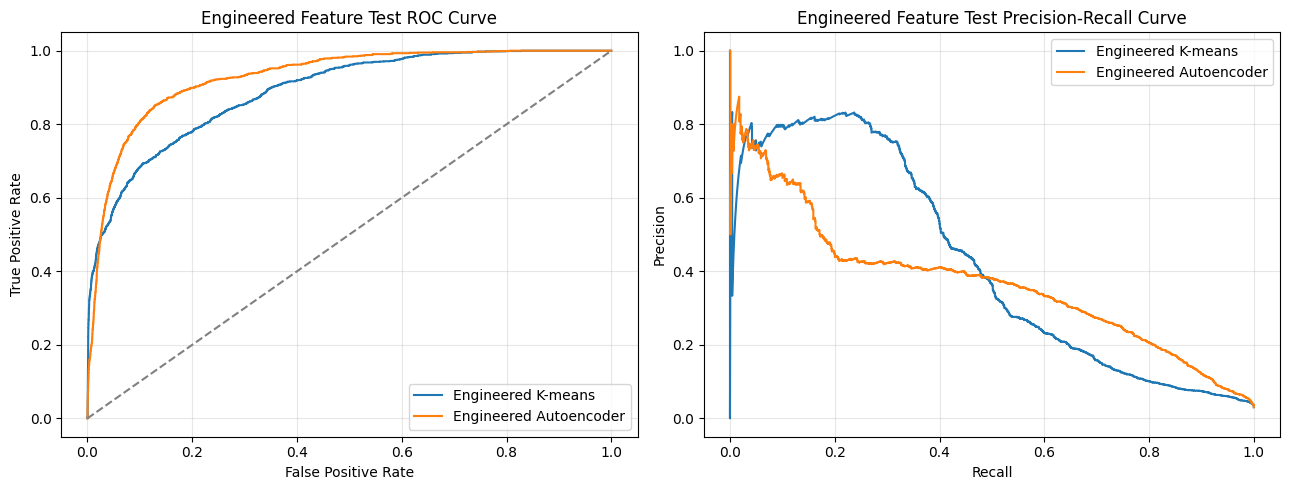

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# Step 4: Plot test ROC and precision-recall curves for the engineered-feature rerun.
brute_test_truth = y_brute_test != "benign"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, scores in [
    ("Engineered K-means", brute_kmeans_test_scores),
    ("Engineered Autoencoder", brute_ae_test_scores),
]:
    fpr_curve, tpr_curve, _ = roc_curve(brute_test_truth, scores)
    curve_precision, curve_recall, _ = precision_recall_curve(brute_test_truth, scores)
    axes[0].plot(fpr_curve, tpr_curve, label=name)
    axes[1].plot(curve_recall, curve_precision, label=name)

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(title="Engineered Feature Test ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].set(title="Engineered Feature Test Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()
